In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

np.random.seed(42)

X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

plt.figure(figsize=(6, 6))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [ ]:
mi_modelo = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
])

mi_modelo.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

mi_modelo.fit(X, Y, epochs=100, verbose=0)

perdida, accuracy = mi_modelo.evaluate(X, Y)
print(f"Modelo Profundo - Accuracy: {accuracy:.4f}")

In [5]:
def plot_decision_boundary(modelo, X, Y, titulo):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
    plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon",  label="Clase 1")
    plt.title(titulo)
    plt.legend()
    plt.show()

Modelo de Una Capa - Accuracy: 0.5100


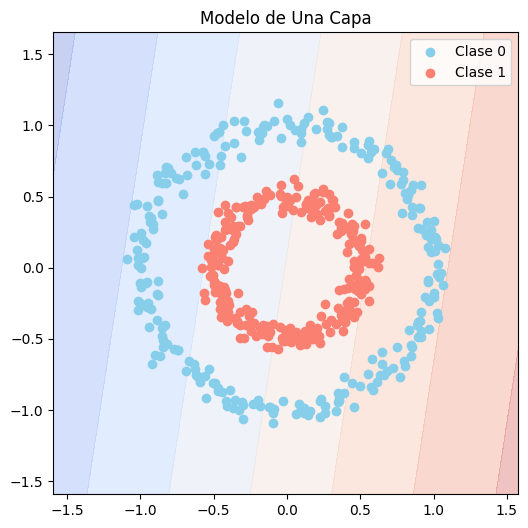

In [6]:
modelo_simple = Sequential([
    Dense(1, activation='sigmoid', input_shape=(2,))
])

modelo_simple.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

modelo_simple.fit(X, Y, epochs=100, verbose=0)

perdida_simple, accuracy_simple = modelo_simple.evaluate(X, Y, verbose=0)
print(f"Modelo de Una Capa - Accuracy: {accuracy_simple:.4f}")

plot_decision_boundary(modelo_simple, X, Y, "Modelo de Una Capa")